In [1]:
import random

from viz import draw_state
import numpy as np
from env import SimpleARGEnvironment
from rollout_worker_arg import RolloutWorker
from tb_gfn import TBGFlowNetGenerator


In [6]:
Ne = 10000
r_per_bp = 1
sequence_length = 4

rho = 4 * Ne * r_per_bp * sequence_length

In [7]:
env = SimpleARGEnvironment(
        num_sequences=4,
        sequence_length=sequence_length,
        rho=rho,
        sequences=["ATCG", "ATCG", "ATCG", "ATCG"],
        fixed_edge_length=0.02,
        rng=random.Random(7),
    )

generator = TBGFlowNetGenerator(env)
rollout_worker = RolloutWorker(env)

{'batch_input': tensor([[[1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0.]]]), 'batch_seq_features': tensor([[[[1., 0., 0., 0.],
          [0., 0., 0., 1.],
          [0., 1., 0., 0.],
          [0., 0., 1., 0.]],

         [[1., 0., 0., 0.],
          [0., 0., 0., 1.],
          [0., 1., 0., 0.],
          [0., 0., 1., 0.]],

         [[1., 0., 0., 0.],
          [0., 0., 0., 1.],
          [0., 1., 0., 0.],
          [0., 0., 1., 0.]],

         [[1., 0., 0., 0.],
          [0., 0., 0., 1.],
          [0., 1., 0., 0.],
          [0., 0., 1., 0.]]]]), 'batch_nb_seq': tensor([4]), 'batch_size': 1, 'batch_traj_idx': tensor([0]), 'random_spec': None}


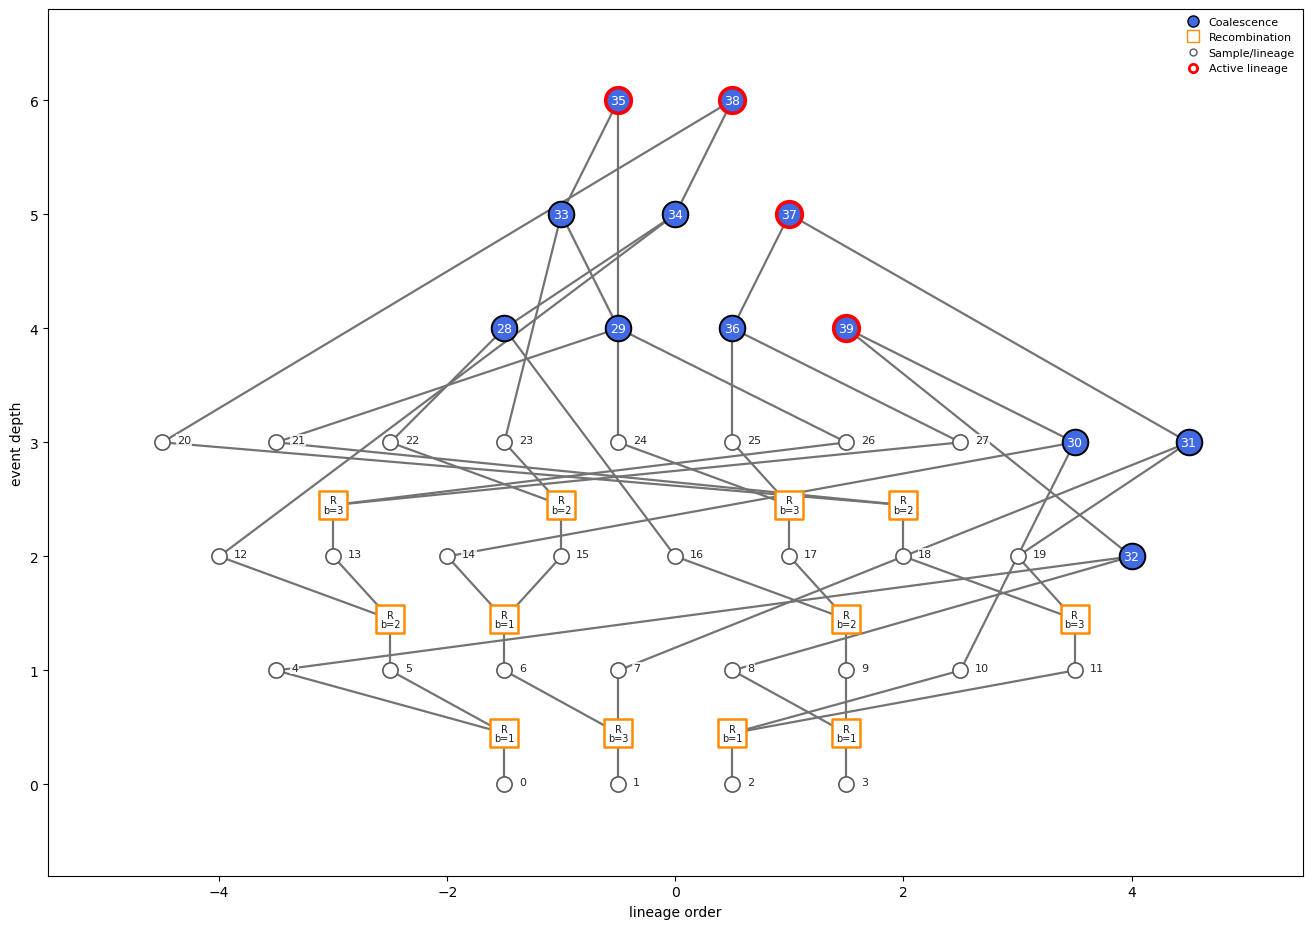

(<Figure size 1500x940 with 1 Axes>,
 <Axes: xlabel='lineage order', ylabel='event depth'>)

In [8]:
state, traj = rollout_worker.rollout(generator)
draw_state(state[0])

In [9]:
act_seg = env.get_arg_sequence_segments(state[0])
[(b['child_node_id'], b['parent_node_ids']) for b in act_seg['recombination_events']]

[(0, {'left': 4, 'right': 5}),
 (1, {'left': 6, 'right': 7}),
 (3, {'left': 8, 'right': 9}),
 (2, {'left': 10, 'right': 11}),
 (5, {'left': 12, 'right': 13}),
 (6, {'left': 14, 'right': 15}),
 (9, {'left': 16, 'right': 17}),
 (11, {'left': 18, 'right': 19}),
 (18, {'left': 20, 'right': 21}),
 (15, {'left': 22, 'right': 23}),
 (17, {'left': 24, 'right': 25}),
 (13, {'left': 26, 'right': 27})]

In [ ]:
init_state = env.get_initial_state()
actions = env.enumerate_actions(init_state)
print(init_state.rates)
probs = env.compute_event_probabilities(init_state)
print(probs)
draw_state(init_state)
len(actions)

In [ ]:
action, log_prior = rollout_worker.sample_action_from_prior(init_state)

In [ ]:
action

In [ ]:
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = init_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)

In [ ]:
distribution = env.compute_action_prior_distribution(init_state, chosen_event)

In [ ]:
# randomly choose from the distribution using log probs (with np.random.choice)
if distribution:
    actions, log_priors = zip(*distribution)
    priors = np.array(log_priors)
    max_log = np.max(priors)
    weights = np.exp(priors - max_log)
    probs = weights / weights.sum()
    chosen_idx = np.random.choice(np.arange(len(actions)), p=probs)
    chosen_action = actions[chosen_idx]
    chosen_log_prior = log_priors[chosen_idx]
    print("Chosen action:", chosen_action)
    print("Log prior:", chosen_log_prior)
else:
    print("No available actions in distribution")

In [ ]:
next_state = env.apply_action(init_state, action)
draw_state(next_state)

In [ ]:
actions = env.enumerate_actions(next_state)
print(next_state.rates)
probs = env.compute_event_probabilities(next_state)
print(probs)
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = next_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)
next_state = env.apply_action(next_state, action)
draw_state(next_state)


In [ ]:
actions = env.enumerate_actions(next_state)
print(next_state.rates)
probs = env.compute_event_probabilities(next_state)
print(probs)
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = next_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)
next_state = env.apply_action(next_state, action)
draw_state(next_state)


In [ ]:
actions = env.enumerate_actions(next_state)
print(next_state.rates)
probs = env.compute_event_probabilities(next_state)
print(probs)
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = next_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)
next_state = env.apply_action(next_state, action)
draw_state(next_state)


In [ ]:
actions = env.enumerate_actions(next_state)
print(next_state.rates)
probs = env.compute_event_probabilities(next_state)
print(probs)
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = next_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)
next_state = env.apply_action(next_state, action)
draw_state(next_state)


In [ ]:
actions = env.enumerate_actions(next_state)
print(next_state.rates)
probs = env.compute_event_probabilities(next_state)
print(probs)
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = next_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)
next_state = env.apply_action(next_state, action)
draw_state(next_state)


In [ ]:
actions = env.enumerate_actions(next_state)
print(next_state.rates)
probs = env.compute_event_probabilities(next_state)
print(probs)
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = next_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)
next_state = env.apply_action(next_state, action)
draw_state(next_state)


In [ ]:
actions = env.enumerate_actions(next_state)
print(next_state.rates)
probs = env.compute_event_probabilities(next_state)
print(probs)
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = next_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)
next_state = env.apply_action(next_state, action)
draw_state(next_state)


In [ ]:
actions = env.enumerate_actions(next_state)
print(next_state.rates)
probs = env.compute_event_probabilities(next_state)
print(probs)
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = next_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)
next_state = env.apply_action(next_state, action)
draw_state(next_state)


In [ ]:
actions = env.enumerate_actions(next_state)
print(next_state.rates)
probs = env.compute_event_probabilities(next_state)
print(probs)
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = next_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)
next_state = env.apply_action(next_state, action)
draw_state(next_state)


In [ ]:
actions = env.enumerate_actions(next_state)
print(next_state.rates)
probs = env.compute_event_probabilities(next_state)
print(probs)
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = next_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)
next_state = env.apply_action(next_state, action)
draw_state(next_state)


In [ ]:
actions = env.enumerate_actions(next_state)
print(next_state.rates)
probs = env.compute_event_probabilities(next_state)
print(probs)
event_types = list(probs.keys())
event_probs = list(probs.values())
chosen_event = np.random.choice(event_types, p=event_probs)
print("Chosen event:", chosen_event)
coal_event, _, recomb_event = next_state.action_options
if chosen_event == "coal":
    action = np.random.choice(coal_event)
else:
    action = np.random.choice(recomb_event)
print(action)
next_state = env.apply_action(next_state, action)
draw_state(next_state)


In [ ]:
next_state.active_lineages